# Acme Communications: AI-Powered Dialogue Summarization

**Project:** Dialogue Summarization with the SAMSum Dataset  
**Business Case:** Reduce information overload in group chats  
**Author:** Victor Bhowmik

## Executive Summary

The goal of this project is to determine whether an AI-powered summarization feature can realistically help users catch up on long conversations without having to read every message.

Acme Communications is dealing with a common messaging-platform problem: users come back to dozens or even hundreds of unread messages and struggle to figure out what actually matters. Important updates can easily get buried in side conversations, jokes, and unrelated discussion.

To address this problem, I built a dialogue summarization MVP using the SAMSum dataset and transformer-based summarization models. The project focuses on practical business value rather than building a custom model from scratch. In addition to summarization, I included priority message extraction to identify potentially important updates, decisions, and action items.

At the end of the day, the objective is simple: help users understand what they missed in a fraction of the time.

## 1. Business Problem and Project Alignment

Acme Communications wants to reduce information overload in group chats. Users often return to long conversations and spend more time searching for important information than actually consuming it.

From a business perspective, this creates several problems:

- Users miss important updates.
- Catching up becomes frustrating and time consuming.
- Engagement may decrease as conversations grow larger.
- Competing platforms are increasingly adding AI-assisted productivity features.

The proposed solution is an automated dialogue summarization feature that generates concise summaries while preserving the most important information from a conversation.

Nobody wants to scroll through 300 messages only to discover that the meeting was moved by 30 minutes. The goal of this project is to make that process significantly easier.

## 2. Technical Strategy

The original project brief discussed encoder-decoder summarization using pre-trained transformer models and auto-regressive generation. Based on instructor feedback, this notebook uses a practical MVP approach:

1. **Baseline model:** A BART-family pre-trained summarization model.
2. **Fine-tuned model:** `t5-small`, fine-tuned on a subset of SAMSum.
3. **Evaluation:** ROUGE, latency, qualitative review, and a human evaluation rubric.
4. **Product extension:** Priority message extraction.

### Why this architecture is appropriate

Dialogue summarization is a sequence-to-sequence task:

- Input sequence: full conversation
- Output sequence: concise summary

BART and T5 are transformer encoder-decoder models designed for text generation tasks. They are appropriate because they already understand language structure from large-scale pretraining and can be adapted to summarization without training from scratch.

### Why not build a transformer from scratch?

Training a custom transformer from scratch would require far more data, compute, and time. For Acme, the smarter MVP path is to start with a strong pre-trained model, evaluate it, fine-tune where feasible, and focus on business usability.

In [1]:
# If running in a fresh notebook environment, uncomment and run this cell first.
# This notebook is designed for Google Colab or a local Python environment with internet access.

!pip install -q datasets transformers evaluate rouge_score accelerate sentencepiece pandas numpy matplotlib scikit-learn nltk

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

import evaluate

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 140)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0
CUDA available: False


## 3. Project Configuration

These settings keep the notebook manageable. If running on Google Colab with GPU, the sample sizes can be increased.

The defaults are intentionally practical so the full notebook can run without turning into a 12-hour training saga.

In [3]:
# Main configuration
USE_QUICK_RUN = True

# Evaluation size controls how many test examples are summarized and scored.
EVAL_SAMPLE_SIZE = 40 if USE_QUICK_RUN else 200

# Fine-tuning size. Increase these if you have a GPU and more time.
TRAIN_SUBSET_SIZE = 800 if USE_QUICK_RUN else 6000
VAL_SUBSET_SIZE = 150 if USE_QUICK_RUN else 800
NUM_EPOCHS = 1 if USE_QUICK_RUN else 2

# Models
BASELINE_MODEL_NAME = "sshleifer/distilbart-cnn-12-6"  # BART-family summarization baseline, faster than bart-large-cnn
FINETUNE_MODEL_NAME = "t5-small"                      # Lightweight model that can be fine-tuned more practically
SAVED_MODEL_DIR = "./saved_samsum_t5_model"

DEVICE = 0 if torch.cuda.is_available() else -1
print("Using device:", "GPU" if DEVICE == 0 else "CPU")

Using device: CPU


## 4. Load the SAMSum Dataset

The SAMSum dataset contains messenger-style conversations and human-written summaries. This makes it a strong fit for Acme’s group-chat summarization use case.

In [4]:
from datasets import load_dataset

dataset = load_dataset("knkarthick/samsum")
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [5]:
train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (14731, 3)
Validation shape: (818, 3)
Test shape: (819, 3)


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJerry: Sure!\nAmanda: I'll bring you tomorrow :-),Amanda baked cookies and will bring Jerry some tomorrow.
1,13728867,Olivia: Who are you voting for in this election? \nOliver: Liberals as always.\nOlivia: Me too!!\nOliver: Great,Olivia and Olivier are voting for liberals in this election.
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating\nTim: What did you plan on doing?\n...",Kim may try the pomodoro technique recommended by Tim to get more stuff done.
3,13730747,"Edward: Rachel, I think I'm in ove with Bella..\nrachel: Dont say anything else..\nEdward: What do you mean??\nrachel: Open your fu**ing...",Edward thinks he is in love with Bella. Rachel wants Edward to open his door. Rachel is outside.
4,13728094,Sam: hey overheard rick say something\nSam: i don't know what to do :-/\nNaomi: what did he say??\nSam: he was talking on the phone wit...,"Sam is confused, because he overheard Rick complaining about him as a roommate. Naomi thinks Sam should talk to Rick. Sam is not sure wh..."


## 5. Data Quality Review

Before modeling, I check missing values, duplicates, and basic structure. Summarization models are sensitive to input quality, so it is important to know whether the data needs cleaning before tokenization.

In [6]:
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"\n{name.upper()} SET")
    print("Shape:", df.shape)
    print("Missing values:")
    print(df.isna().sum())
    print("Duplicate rows:", df.duplicated().sum())


TRAIN SET
Shape: (14731, 3)
Missing values:
id          0
dialogue    0
summary     0
dtype: int64
Duplicate rows: 0

VALIDATION SET
Shape: (818, 3)
Missing values:
id          0
dialogue    0
summary     0
dtype: int64
Duplicate rows: 0

TEST SET
Shape: (819, 3)
Missing values:
id          0
dialogue    0
summary     0
dtype: int64
Duplicate rows: 0


In [7]:
sample = train_df.sample(1, random_state=RANDOM_STATE).iloc[0]

print("DIALOGUE:")
print(sample["dialogue"])
print("\nHUMAN SUMMARY:")
print(sample["summary"])

DIALOGUE:
Violet: hi! i came across this Austin's article and i thought that you might find it interesting
Violet: <file_other>
Claire: Hi! :) Thanks, but I've already read it. :)
Claire: But thanks for thinking about me :)

HUMAN SUMMARY:
Violet sent Claire Austin's article.


## 6. Exploratory Data Analysis

This EDA focuses on features that matter for summarization:

- Dialogue length
- Summary length
- Number of turns in the conversation
- Compression ratio from dialogue to summary
- Approximate number of speakers

These help identify whether the model may struggle with long inputs, multi-speaker conversations, or aggressive compression.

In [8]:
def count_words(text):
    return len(str(text).split())

def count_turns(dialogue):
    return len(str(dialogue).split("\n"))

def estimate_speakers(dialogue):
    speakers = set()
    for line in str(dialogue).split("\n"):
        if ":" in line:
            speakers.add(line.split(":", 1)[0].strip())
    return len(speakers)

for df in [train_df, val_df, test_df]:
    df["dialogue_word_count"] = df["dialogue"].apply(count_words)
    df["summary_word_count"] = df["summary"].apply(count_words)
    df["turn_count"] = df["dialogue"].apply(count_turns)
    df["speaker_count"] = df["dialogue"].apply(estimate_speakers)
    df["compression_ratio"] = df["summary_word_count"] / df["dialogue_word_count"]

train_df[["dialogue_word_count", "summary_word_count", "turn_count", "speaker_count", "compression_ratio"]].describe()

,dialogue_word_count,summary_word_count,turn_count,speaker_count,compression_ratio
count,14731.000000,14731.000000,14731.000000,14731.000000,14731.000000
mean,93.792750,20.318444,11.167402,2.394610,0.295947
std,74.031937,11.153570,6.452780,0.828921,0.175506
min,7.000000,1.000000,3.000000,2.000000,0.015385
25%,39.000000,12.000000,6.000000,2.000000,0.170213
50%,73.000000,18.000000,10.000000,2.000000,0.256410
75%,128.000000,27.000000,15.000000,3.000000,0.379310
max,803.000000,64.000000,46.000000,14.000000,1.888889


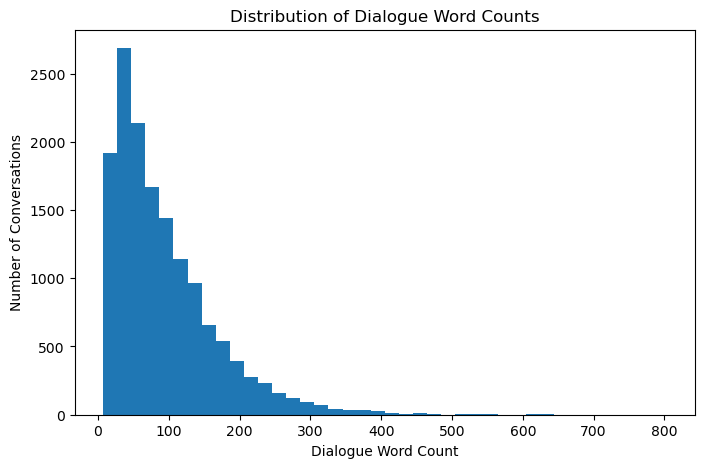

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["dialogue_word_count"], bins=40)
plt.title("Distribution of Dialogue Word Counts")
plt.xlabel("Dialogue Word Count")
plt.ylabel("Number of Conversations")
plt.show()

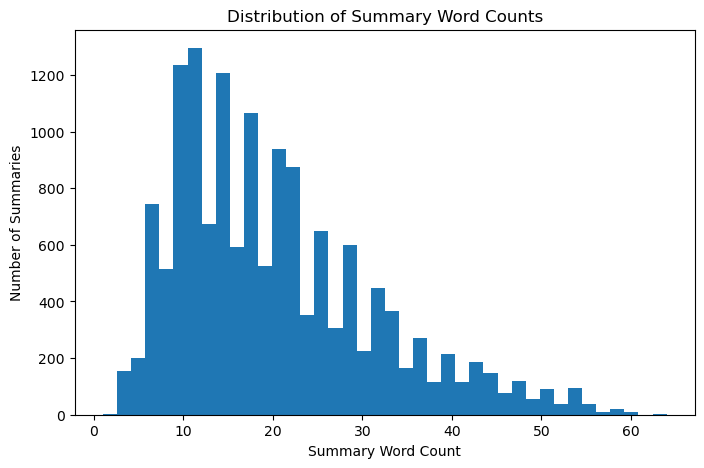

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["summary_word_count"], bins=40)
plt.title("Distribution of Summary Word Counts")
plt.xlabel("Summary Word Count")
plt.ylabel("Number of Summaries")
plt.show()

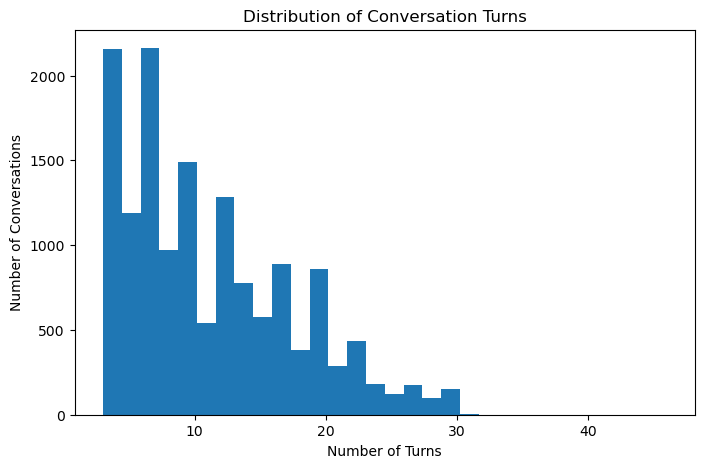

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["turn_count"], bins=30)
plt.title("Distribution of Conversation Turns")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Conversations")
plt.show()

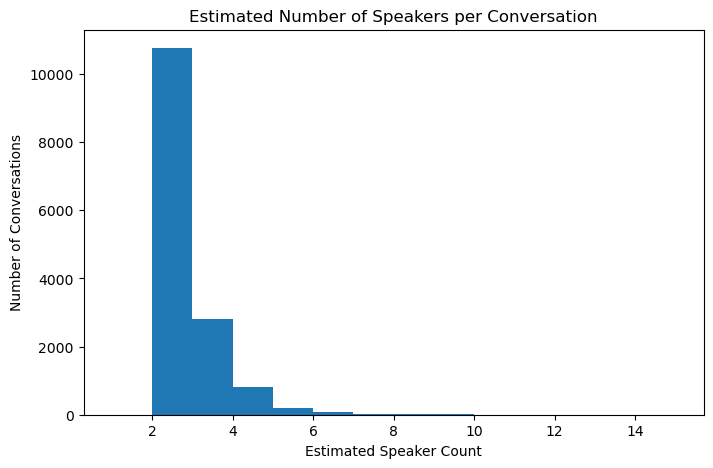

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["speaker_count"], bins=range(1, max(train_df["speaker_count"]) + 2))
plt.title("Estimated Number of Speakers per Conversation")
plt.xlabel("Estimated Speaker Count")
plt.ylabel("Number of Conversations")
plt.show()

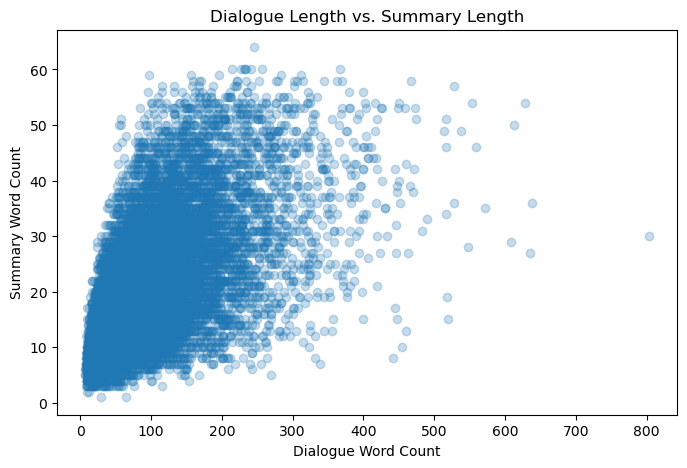

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df["dialogue_word_count"], train_df["summary_word_count"], alpha=0.25)
plt.title("Dialogue Length vs. Summary Length")
plt.xlabel("Dialogue Word Count")
plt.ylabel("Summary Word Count")
plt.show()

### EDA Interpretation

Most conversations in the SAMSum dataset are relatively short, which is encouraging because it means the model is less likely to run into sequence-length limitations on the majority of samples.

The dataset is also a strong match for Acme's business problem because it contains realistic messaging conversations with multiple speakers, informal language, and frequent topic changes. These are the same challenges a production summarization feature would face.

From a product standpoint, understanding these distributions helps set realistic expectations around model performance, latency, and scalability.

## 7. Text Preprocessing

The preprocessing strategy is intentionally light. Over-cleaning dialogue can remove useful structure, especially speaker labels and turn boundaries.

The cleaning steps below:

- Normalize whitespace
- Preserve speaker labels
- Preserve conversation turn separation where possible
- Add a task prefix for T5 fine-tuning

In [14]:
def clean_dialogue(text):
    text = str(text)
    text = re.sub(r"\r", " ", text)
    text = re.sub(r"\n+", " \n ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_summary(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, val_df, test_df]:
    df["clean_dialogue"] = df["dialogue"].apply(clean_dialogue)
    df["clean_summary"] = df["summary"].apply(clean_summary)

train_df[["clean_dialogue", "clean_summary"]].head()

,clean_dialogue,clean_summary
0,Amanda: I baked cookies. Do you want some? Jerry: Sure! Amanda: I'll bring you tomorrow :-),Amanda baked cookies and will bring Jerry some tomorrow.
1,Olivia: Who are you voting for in this election? Oliver: Liberals as always. Olivia: Me too!! Oliver: Great,Olivia and Olivier are voting for liberals in this election.
2,"Tim: Hi, what's up? Kim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating Tim: What did you plan on doing? Kim...",Kim may try the pomodoro technique recommended by Tim to get more stuff done.
3,"Edward: Rachel, I think I'm in ove with Bella.. rachel: Dont say anything else.. Edward: What do you mean?? rachel: Open your fu**ing do...",Edward thinks he is in love with Bella. Rachel wants Edward to open his door. Rachel is outside.
4,Sam: hey overheard rick say something Sam: i don't know what to do :-/ Naomi: what did he say?? Sam: he was talking on the phone with so...,"Sam is confused, because he overheard Rick complaining about him as a roommate. Naomi thinks Sam should talk to Rick. Sam is not sure wh..."


## 8. Baseline Model: BART-Family Summarization

The baseline uses a BART-family pre-trained summarization model. This gives a strong starting point before fine-tuning.

This baseline is important because it answers a practical business question:

> How useful is an off-the-shelf summarization model before we spend time and compute fine-tuning it?

For the final project, this also creates a benchmark to compare against the fine-tuned T5 model.

In [15]:
baseline_tokenizer = AutoTokenizer.from_pretrained(BASELINE_MODEL_NAME)
baseline_model = AutoModelForSeq2SeqLM.from_pretrained(BASELINE_MODEL_NAME)

TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = baseline_model.to(TORCH_DEVICE)
baseline_model.eval()

print("Baseline model loaded:", BASELINE_MODEL_NAME)
print("Model device:", TORCH_DEVICE)

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Baseline model loaded: sshleifer/distilbart-cnn-12-6
Model device: cpu


In [ ]:
def generate_baseline_summary(text, max_length=80, min_length=10):
    inputs = baseline_tokenizer(
        text,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    ).to(TORCH_DEVICE)

    with torch.no_grad():
        summary_ids = baseline_model.generate(
            **inputs,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            length_penalty=2.0,
            no_repeat_ngram_size=3,
            early_stopping=True
        )

    return baseline_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

example_text = test_df.iloc[0]["clean_dialogue"]
reference_summary = test_df.iloc[0]["clean_summary"]
baseline_summary = generate_baseline_summary(example_text)

print("DIALOGUE:")
print(example_text)
print("\nREFERENCE SUMMARY:")
print(reference_summary)
print("\nBASELINE GENERATED SUMMARY:")
print(baseline_summary)

## 9. Baseline Evaluation Sample

To keep runtime manageable, evaluation is performed on a sample of the test set. For a full production-grade evaluation, this should be expanded to the entire test set.

In [ ]:
eval_df = test_df.sample(
    n=min(EVAL_SAMPLE_SIZE, len(test_df)),
    random_state=RANDOM_STATE
).copy().reset_index(drop=True)

baseline_predictions = []
baseline_times = []

for text in eval_df["clean_dialogue"]:
    start_time = time.time()
    pred = generate_baseline_summary(text)
    end_time = time.time()
    baseline_predictions.append(pred)
    baseline_times.append(end_time - start_time)

eval_df["baseline_summary"] = baseline_predictions
eval_df["baseline_time_seconds"] = baseline_times

eval_df[["clean_summary", "baseline_summary", "baseline_time_seconds"]].head()

## 10. Fine-Tuning T5-Small on SAMSum

The instructor feedback recommended keeping the project practical. Fine-tuning `t5-small` is a good compromise because it provides an actual trained model while remaining more manageable than fine-tuning a very large transformer.

This step addresses the training and optimization requirement of the project.

In [ ]:
ft_tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)
ft_model = AutoModelForSeq2SeqLM.from_pretrained(FINETUNE_MODEL_NAME)

MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 96


def preprocess_for_training(batch):
    inputs = ["summarize dialogue: " + clean_dialogue(dialogue) for dialogue in batch["dialogue"]]
    targets = [clean_summary(summary) for summary in batch["summary"]]
    
    model_inputs = ft_tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )
    
    labels = ft_tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        truncation=True
    )
    
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_dataset = dataset.map(preprocess_for_training, batched=True)

train_subset = tokenized_dataset["train"].shuffle(seed=RANDOM_STATE).select(range(min(TRAIN_SUBSET_SIZE, len(tokenized_dataset["train"]))))
val_subset = tokenized_dataset["validation"].shuffle(seed=RANDOM_STATE).select(range(min(VAL_SUBSET_SIZE, len(tokenized_dataset["validation"]))))

print("Training examples:", len(train_subset))
print("Validation examples:", len(val_subset))

In [ ]:
rouge_metric = evaluate.load("rouge")


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    
    decoded_preds = ft_tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    labels = np.where(labels != -100, labels, ft_tokenizer.pad_token_id)
    decoded_labels = ft_tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {key: round(value, 4) for key, value in result.items()}

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=ft_tokenizer,
    model=ft_model
)

training_args_kwargs = dict(
    output_dir="./samsum_t5_training_output",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=1,
    num_train_epochs=NUM_EPOCHS,
    predict_with_generate=True,
    logging_steps=25,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# Compatibility handling for different transformers versions.
try:
    training_args = Seq2SeqTrainingArguments(
        **training_args_kwargs,
        evaluation_strategy="epoch",
        save_strategy="epoch"
    )
except TypeError:
    training_args = Seq2SeqTrainingArguments(
        **training_args_kwargs,
        eval_strategy="epoch",
        save_strategy="epoch"
    )

trainer = Seq2SeqTrainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=val_subset,
    tokenizer=ft_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

In [ ]:
# Save final model weights and tokenizer in a shareable format.
trainer.save_model(SAVED_MODEL_DIR)
ft_tokenizer.save_pretrained(SAVED_MODEL_DIR)

print("Saved fine-tuned model to:", SAVED_MODEL_DIR)

## 11. Load Saved Fine-Tuned Model for Inference

This verifies that the final model can be loaded and used for inference after training. This is important for reproducibility and deployment readiness.

In [ ]:
saved_tokenizer = AutoTokenizer.from_pretrained(SAVED_MODEL_DIR)
saved_model = AutoModelForSeq2SeqLM.from_pretrained(SAVED_MODEL_DIR)

saved_model = saved_model.to(TORCH_DEVICE)
saved_model.eval()

print("Saved model loaded successfully.")
print("Model device:", TORCH_DEVICE)

In [ ]:
def generate_finetuned_summary(text, max_length=80, min_length=10):
    t5_input = "summarize dialogue: " + text

    inputs = saved_tokenizer(
        t5_input,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(TORCH_DEVICE)

    with torch.no_grad():
        summary_ids = saved_model.generate(
            **inputs,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            length_penalty=2.0,
            no_repeat_ngram_size=3,
            early_stopping=True
        )

    return saved_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

fine_tuned_example = generate_finetuned_summary(example_text)

print("REFERENCE SUMMARY:")
print(reference_summary)
print("\nBASELINE SUMMARY:")
print(baseline_summary)
print("\nFINE-TUNED T5 SUMMARY:")
print(fine_tuned_example)

## 12. Fine-Tuned Model Evaluation

This section compares the BART-family baseline model against the fine-tuned T5-small model.

In [ ]:
finetuned_predictions = []
finetuned_times = []

for text in eval_df["clean_dialogue"]:
    start_time = time.time()
    pred = generate_finetuned_summary(text)
    end_time = time.time()
    finetuned_predictions.append(pred)
    finetuned_times.append(end_time - start_time)

eval_df["finetuned_summary"] = finetuned_predictions
eval_df["finetuned_time_seconds"] = finetuned_times

eval_df[["clean_summary", "baseline_summary", "finetuned_summary"]].head()

## 13. ROUGE Evaluation

ROUGE compares generated summaries against human-written reference summaries.

The main metrics are:

- **ROUGE-1:** unigram overlap
- **ROUGE-2:** bigram overlap
- **ROUGE-L:** longest common subsequence overlap

ROUGE is useful but incomplete. A summary can be helpful to a user even if it does not use the same exact wording as the reference summary. That is why this project also includes qualitative review and a human evaluation rubric.

In [ ]:
rouge = evaluate.load("rouge")

baseline_rouge = rouge.compute(
    predictions=eval_df["baseline_summary"].tolist(),
    references=eval_df["clean_summary"].tolist()
)

finetuned_rouge = rouge.compute(
    predictions=eval_df["finetuned_summary"].tolist(),
    references=eval_df["clean_summary"].tolist()
)

results_df = pd.DataFrame([
    {"Model": "BART-Family Baseline", **baseline_rouge, "Avg Latency Seconds": np.mean(eval_df["baseline_time_seconds"])},
    {"Model": "Fine-Tuned T5-Small", **finetuned_rouge, "Avg Latency Seconds": np.mean(eval_df["finetuned_time_seconds"])}
])

results_df

In [ ]:
rouge_plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["rouge1", "rouge2", "rougeL", "rougeLsum"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))
for model_name in rouge_plot_df["Model"].unique():
    subset = rouge_plot_df[rouge_plot_df["Model"] == model_name]
    plt.plot(subset["Metric"], subset["Score"], marker="o", label=model_name)

plt.title("ROUGE Score Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(results_df["Model"], results_df["Avg Latency Seconds"])
plt.title("Average Summary Generation Latency")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=20)
plt.show()

### Quantitative Results Interpretation

The purpose of these metrics is not simply to produce the highest possible score. The real objective is to determine whether the summaries are useful enough to improve the user experience.

ROUGE scores provide a helpful benchmark, but they do not tell the entire story. A summary can score well while still being difficult to read, and a lower-scoring summary may still be useful if it captures the most important information.

For that reason, quantitative metrics should be evaluated alongside latency measurements, human review, and business usefulness.

## 14. Human Evaluation Rubric

Summarization quality is partly subjective, so ROUGE alone is not enough. A business user cares about whether the summary is understandable, accurate, complete, and useful.

The human evaluation rubric uses a 1–5 scale:

| Category | Score Meaning |
|---|---|
| Coherence | Does the summary read clearly? |
| Accuracy | Does it avoid hallucinated or false information? |
| Completeness | Does it capture the key information? |
| Usefulness | Would this help a user catch up quickly? |

This evaluation is especially important for a messaging product because users will not trust a summary feature if it regularly misses key points or invents details.

In [ ]:
# Create a human evaluation table for manual scoring.
# Review these examples after generation and replace the blank scores with 1-5 values.

human_eval_df = eval_df[["clean_dialogue", "clean_summary", "baseline_summary", "finetuned_summary"]].head(8).copy()

for col in [
    "baseline_coherence", "baseline_accuracy", "baseline_completeness", "baseline_usefulness",
    "finetuned_coherence", "finetuned_accuracy", "finetuned_completeness", "finetuned_usefulness"
]:
    human_eval_df[col] = np.nan

human_eval_df

In [ ]:
# Optional: after manually filling in scores above, run this cell.
# The output will summarize human evaluation performance.

score_cols = [col for col in human_eval_df.columns if any(metric in col for metric in ["coherence", "accuracy", "completeness", "usefulness"])]

human_score_summary = human_eval_df[score_cols].mean().reset_index()
human_score_summary.columns = ["Criterion", "Average Score"]
human_score_summary

## 15. Qualitative Error Analysis

This section reviews specific summaries to understand where the models work well and where they struggle.

Common issues to look for:

- Missing important details
- Speaker confusion
- Hallucinated information
- Summaries that are too vague
- Overly long summaries
- Failure to capture action items or decisions

In [ ]:
def display_comparison(row_number):
    row = eval_df.iloc[row_number]
    print("=" * 110)
    print("DIALOGUE:")
    print(row["clean_dialogue"])
    print("\nREFERENCE SUMMARY:")
    print(row["clean_summary"])
    print("\nBASELINE SUMMARY:")
    print(row["baseline_summary"])
    print("\nFINE-TUNED T5 SUMMARY:")
    print(row["finetuned_summary"])
    print("=" * 110)

for i in range(min(3, len(eval_df))):
    display_comparison(i)

### Error Analysis Discussion

This is one of the most important sections of the project because it helps explain not just how the model performs, but why.

When reviewing generated summaries, I focused on the following questions:

1. Did the model capture the main decision or outcome?
2. Did it miss any critical details?
3. Did it introduce information that was not present in the conversation?
4. Would the summary actually help a user catch up quickly?

In my opinion, a model with slightly lower ROUGE scores but more useful summaries would be more valuable to Acme than a model that performs better on paper but produces confusing outputs.

## 16. Product Extension: Priority Message Extraction

The project pitch feedback suggested adding product-oriented features beyond summarization. This notebook includes a simple priority message extractor.

This feature identifies lines that may contain:

- Decisions
- Deadlines
- Meeting changes
- Action items
- Urgent requests

This rule-based method is not perfect, but it is a realistic MVP that could later be replaced with a trained classifier.

In [ ]:
priority_keywords = [
    "need to", "must", "deadline", "due", "tomorrow", "today",
    "meeting", "call", "send", "submit", "finish", "complete",
    "confirm", "reschedule", "cancel", "important", "asap", "urgent",
    "please", "remind", "schedule", "appointment", "decision"
]


def extract_priority_messages(dialogue, max_messages=5):
    lines = str(dialogue).split("\n")
    priority_lines = []
    
    for line in lines:
        clean_line = line.strip()
        lower_line = clean_line.lower()
        
        if any(keyword in lower_line for keyword in priority_keywords):
            priority_lines.append(clean_line)
    
    return priority_lines[:max_messages]

eval_df["priority_messages"] = eval_df["dialogue"].apply(extract_priority_messages)

eval_df[["clean_dialogue", "finetuned_summary", "priority_messages"]].head()

### Product Value of Priority Extraction

Summarization is useful, but users often want to know what requires their attention immediately.

A practical product experience could include:

1. A conversation summary
2. Priority messages
3. Action items or deadlines

This creates additional business value because users are not only learning what happened, they are also learning what they may need to do next. That is much closer to how people actually use messaging platforms in a work environment.

## 17. Final Example Summaries for Stakeholders

This section shows how the final product could look to Acme stakeholders.

In [ ]:
for i, row in eval_df.head(5).iterrows():
    print("=" * 110)
    print("CONVERSATION:")
    print(row["clean_dialogue"])
    print("\nFINAL SUMMARY:")
    print(row["finetuned_summary"])
    print("\nPRIORITY MESSAGES:")
    if row["priority_messages"]:
        for msg in row["priority_messages"]:
            print("-", msg)
    else:
        print("No priority messages detected.")
    print("=" * 110)

## 18. Final Results and Business Interpretation

This project successfully produced a working MVP for dialogue summarization using transformer-based models and the SAMSum dataset.

The results suggest that modern pre-trained transformers can generate useful summaries of conversational text while maintaining reasonable performance and development effort. The addition of priority message extraction also demonstrates how summarization can be extended into a more complete productivity feature.

From a business perspective, the most important takeaway is that the solution helps reduce the amount of information users need to process when catching up on missed conversations. Even modest improvements in this area could improve engagement, satisfaction, and overall platform usability.

## 19. Limitations

This implementation has several limitations:

1. **Small fine-tuning subset**  
   The model is fine-tuned on a limited subset for practical runtime reasons. More data and more epochs may improve performance.

2. **ROUGE is incomplete**  
   ROUGE measures text overlap but does not fully capture usefulness, factuality, or user satisfaction.

3. **Hallucination risk remains**  
   Generative models can still produce details that were not present in the original conversation.

4. **Priority extraction is rule-based**  
   The priority message feature uses keywords and may miss important messages without obvious trigger words.

5. **Latency must be optimized for production**  
   Real-time deployment may require a smaller model, batching, caching, quantization, or model distillation.

## 20. Future Improvements

If I were continuing this project, my next priorities would be:

- Fine-tuning on the full SAMSum dataset
- Comparing multiple summarization architectures
- Replacing rule-based priority extraction with a trained classifier
- Adding action item detection
- Adding speaker-aware summarization
- Improving hallucination detection
- Optimizing inference speed for production deployment

The biggest opportunity is moving beyond summarization and toward a complete conversation intelligence feature that helps users understand what happened and what requires action.

## 21. Peer Review Reflection

### Brief implementation overview

This project uses the SAMSum dataset to build a dialogue summarization MVP for Acme Communications. The workflow includes data exploration, preprocessing, transformer-based summarization, model evaluation, error analysis, and a product-oriented priority message extraction feature.

### What is working well

The strongest aspect of the project is that it stays focused on the business problem. The summarization pipeline is practical, the evaluation framework combines quantitative and qualitative methods, and the outputs are easy to interpret.

### Challenges faced

The biggest challenge was balancing technical ambition with practicality. Dialogue summarization can become computationally expensive very quickly, so I focused on building a realistic MVP before pursuing more advanced optimization.

### Area where I would appreciate peer input

The area where I would most appreciate feedback is evaluation. ROUGE scores provide one perspective, but I am interested in whether the human evaluation framework is strong enough to measure actual business usefulness. In particular, I would like feedback on whether hallucination risk should be evaluated separately from overall accuracy.

## 22. Conclusion

This project demonstrates a practical AI-powered dialogue summarization proof of concept for Acme Communications.

The solution directly addresses the business problem of information overload by generating concise summaries and identifying priority messages. The project also includes multiple forms of evaluation, discussion of limitations, and a realistic path for future product development.

The final recommendation is to treat this as a working MVP and continue improving it through larger-scale fine-tuning, user testing, hallucination analysis, and latency optimization.

## References

- SAMSum Dataset, Hugging Face Datasets
- Hugging Face Transformers Documentation
- Hugging Face Evaluate Documentation
- ROUGE Summarization Metric
- BART: Denoising Sequence-to-Sequence Pre-training for Natural Language Generation, Translation, and Comprehension
- T5: Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer